# Customer Churn Prediction — Telco Customer Churn

## Business Problem

We are a Data Scientist at a telecommunications company. The company wants to identify customers who are likely to **churn** (leave the company) so that the retention team can proactively engage with them before they cancel.

Using the IBM Telco Customer Churn dataset, this notebook builds an **end-to-end machine learning solution** to predict customer churn:

**Business Problem → Data → Preparation → EDA → Feature Engineering → Model → Evaluation → Interpretation → Saved Model → API**

- **Dataset**: IBM Telco Customer Churn Dataset (`data/TelcoCustomerChurn.csv`)
- **Target variable**: `Churn` (Yes / No)
- **Model**: Decision Tree Classifier
- **Train/Test split**: 70:30, `random_state=42`

> Note: All preprocessing / feature-engineering logic lives in [`churn_features.py`](../churn_features.py) (a standalone importable module) so that the exact same transformations are applied consistently to training data **and** to new/unseen data submitted to the API — this avoids data leakage and train/serve skew.


In [1]:
import sys
import os

# Allow importing the shared `churn_features` module from the project root.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
)
import joblib

from churn_features import (
    ChurnFeatureEngineer, RAW_FEATURE_COLUMNS, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "TelcoCustomerChurn.csv")
MODEL_PATH = os.path.join(PROJECT_ROOT, "model", "churn_model.pkl")

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: c:\Users\SESA849778\work\assignments\DS\customer_churn_project
Data path: c:\Users\SESA849778\work\assignments\DS\customer_churn_project\data\TelcoCustomerChurn.csv


## 1. Data Understanding & Preparation

### 1.1 Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Data types and structure check

In [3]:
df.info()
print("\nUnique customerID count:", df["customerID"].nunique(), "/ rows:", len(df))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 1.3 Missing-value analysis & duplicate analysis

`TotalCharges` is loaded as an object/string column (not numeric) — this is a strong hint it contains non-numeric placeholder values (e.g. blank strings) that need to be cleaned before it can be used as a numeric feature.

In [4]:
print("Explicit NaN values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None (0 explicit NaNs)")

blank_total_charges = df["TotalCharges"].astype(str).str.strip() == ""
print(f"\nRows with blank TotalCharges: {blank_total_charges.sum()}")
print(df.loc[blank_total_charges, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

print(f"\nFull-row duplicates: {df.duplicated().sum()}")
print(f"Duplicate customerID values: {df['customerID'].duplicated().sum()}")

Explicit NaN values per column:
None (0 explicit NaNs)

Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

Full-row duplicates: 0
Duplicate customerID values: 0


### 1.4 Numerical vs categorical feature identification

- **Numerical**: `SeniorCitizen` (binary flag), `tenure`, `MonthlyCharges`, `TotalCharges` (after cleaning)
- **Categorical**: `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`
- **Identifier (dropped)**: `customerID` — unique per row, carries no predictive signal, and using it would be a leakage/overfitting risk.
- **Target**: `Churn` (Yes/No)

### 1.5 Target-variable analysis

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
 Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


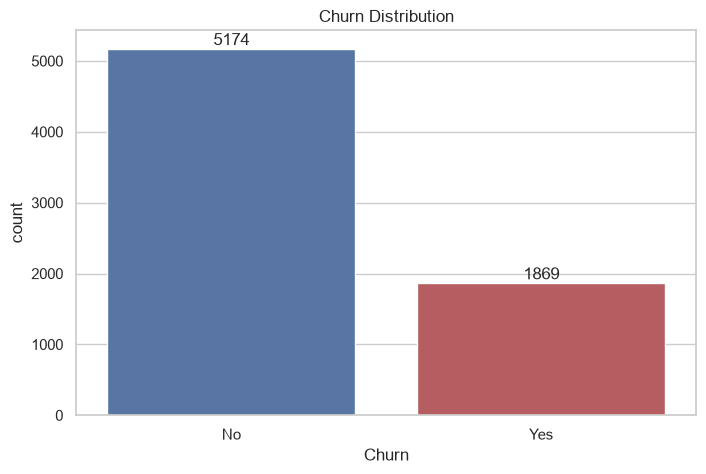

In [5]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_counts)
print("\nChurn rate:\n", churn_rate.round(4))

fig, ax = plt.subplots()
sns.countplot(x="Churn", data=df, hue="Churn", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_title("Churn Distribution")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

**Observation**: The target is **imbalanced** — ~73.5% "No" vs ~26.5% "Yes". This has two implications we address later:
1. Accuracy alone is a misleading metric — we must look at precision/recall/F1 for the minority ("Yes") class.
2. We will experiment with `class_weight="balanced"` in the Decision Tree to counter the imbalance (bonus: handling class imbalance).

### 1.6 Data cleaning, preprocessing & train/test split

**Key preprocessing decisions:**
- Drop `customerID` (identifier, no predictive value).
- `TotalCharges` has 11 blank-string rows, **all** with `tenure == 0`, i.e. brand-new customers who haven't been billed yet. The correct/logical value is `0`, not a random imputed value — so we handle this explicitly.
- Encode the target `Churn`: `Yes → 1`, `No → 0`.
- All other preprocessing (imputation, one-hot encoding, feature engineering) is done **inside a scikit-learn `Pipeline`** fitted only on the training set. This is critical to **avoid data leakage** and to guarantee the exact same transformations apply automatically to new/unseen data at inference time (used later by the Flask API).
- **Split**: 70% train / 30% test, stratified on `Churn`, `random_state=42`.

In [6]:
X = df[RAW_FEATURE_COLUMNS].copy()
y = df["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: {:.4f}".format(y_train.mean()))
print("Test churn rate:  {:.4f}".format(y_test.mean()))

Train shape: (4930, 19)  Test shape: (2113, 19)
Train churn rate: 0.2653
Test churn rate:  0.2655


## 2. Exploratory Data Analysis

> **Note on leakage**: All EDA below is performed on the **full dataset** purely for descriptive/visual understanding (no statistics are learned or fed into the model from this step). The predictive Pipeline (Section 4 onward) is fit strictly on `X_train`/`y_train`.

**Business insight #1 (Churn distribution)**: Roughly 1 in 4 customers (26.5%) have churned historically. This confirms churn is a meaningful, moderately imbalanced problem worth the retention team's attention, and tells us not to rely on plain accuracy for evaluation.

### 2.1 Customer/service characteristics & churn vs key categorical attributes

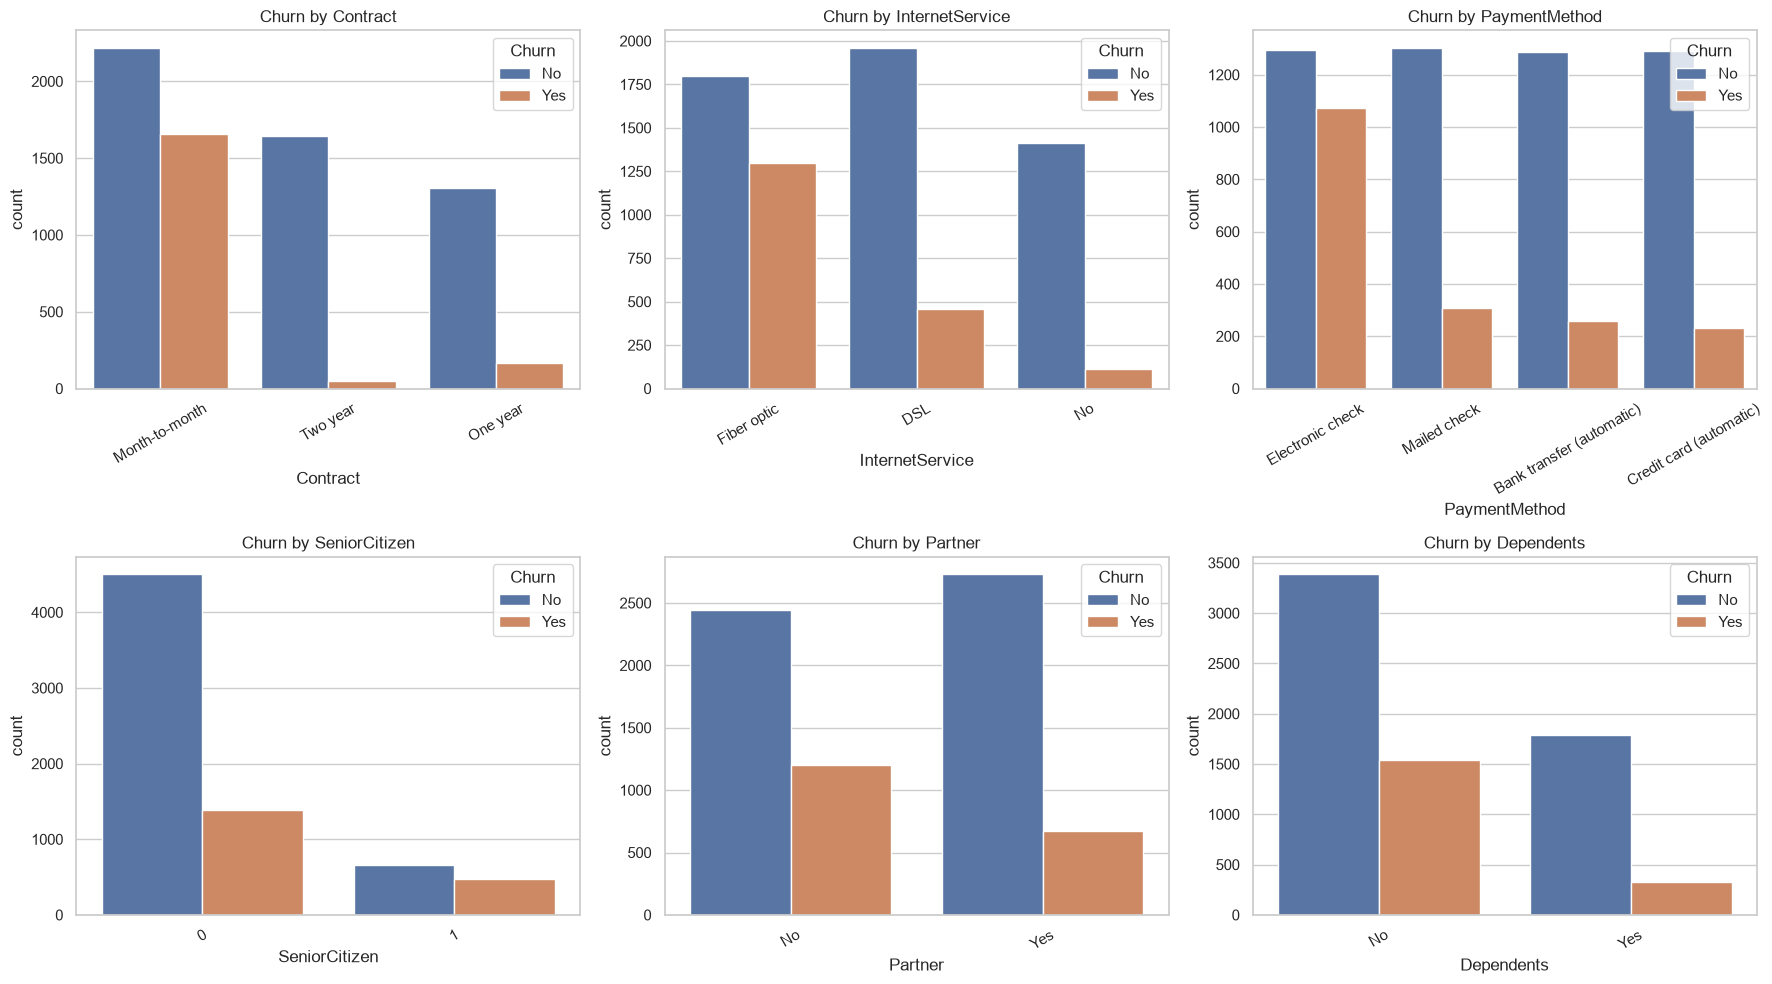

In [7]:
categorical_to_plot = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, categorical_to_plot):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue="Churn", data=df, order=order, ax=ax)
    ax.set_title(f"Churn by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Business insight #2 (Contract & Internet service)**: Month-to-month customers churn at a much higher rate than one/two-year contract customers — churn is essentially a "commitment" problem. Fiber optic internet customers also churn far more than DSL or no-internet customers (likely price/quality sensitivity). **Business insight #3 (Payment/demographics)**: Electronic-check payers, senior citizens, and customers without a partner/dependents all show elevated churn — suggesting these segments are more price-sensitive or less "anchored" to the service.

### 2.2 Numerical variable distributions & relationships with churn

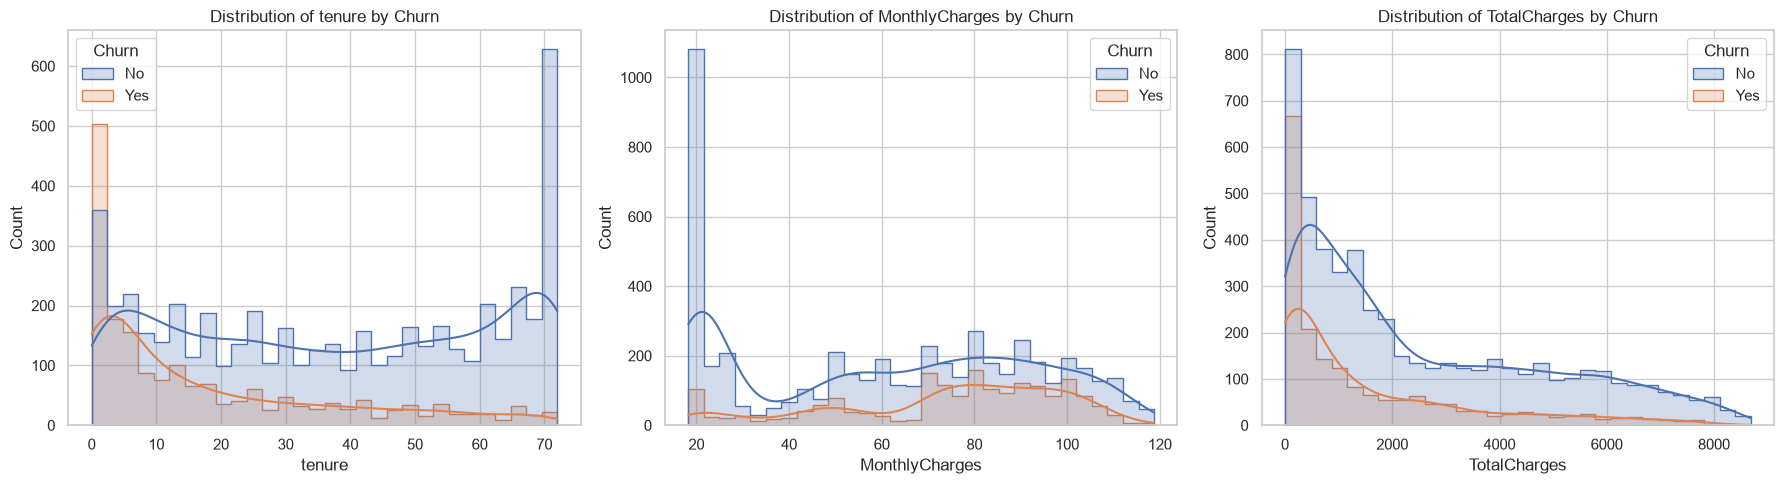

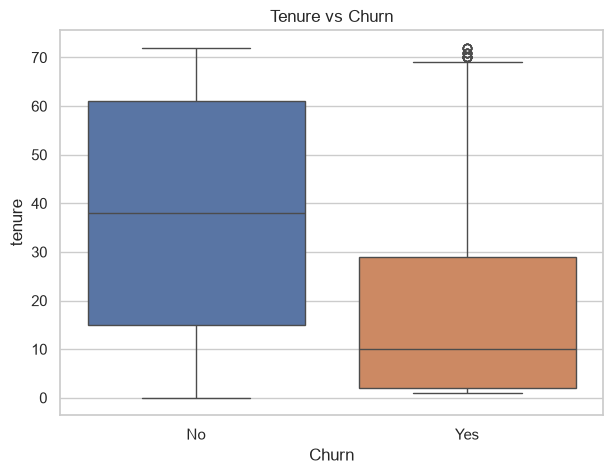

In [8]:
# Local, EDA-only copy with TotalCharges coerced to numeric (blank -> 0 for tenure==0 customers).
df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce").fillna(0)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df_eda, x=col, hue="Churn", kde=True, element="step", ax=ax, bins=30)
    ax.set_title(f"Distribution of {col} by Churn")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x="Churn", y="tenure", data=df_eda, hue="Churn", legend=False, ax=ax)
ax.set_title("Tenure vs Churn")
plt.show()

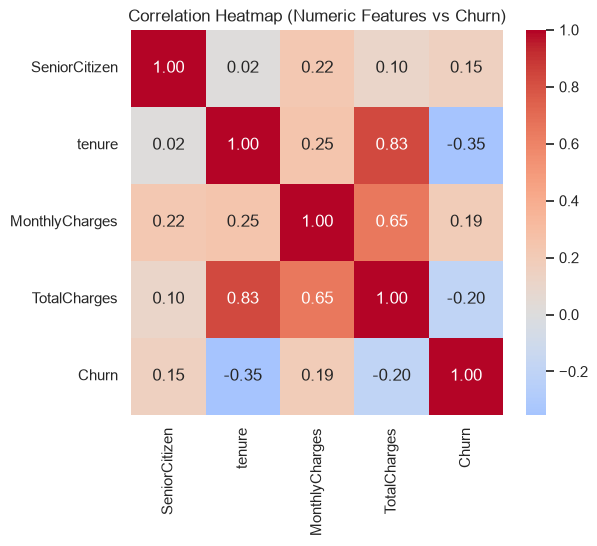

In [9]:
corr_df = df_eda[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn"] = df_eda["Churn"].map({"Yes": 1, "No": 0})

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (Numeric Features vs Churn)")
plt.show()

**Business insight #4 (Tenure & charges)**: `tenure` is the strongest numeric correlate with churn (-0.35) — customers leave earliest in their lifecycle (median tenure ~10 months for churners vs ~38 for non-churners). `MonthlyCharges` correlates positively (+0.19, higher bills → more churn) while `TotalCharges` correlates negatively (-0.20, largely because it's driven by tenure). `tenure` and `TotalCharges` are highly correlated (0.83) as expected, since `TotalCharges` accumulates over time.

**Business insight #5 (Churn distribution recap)**: Combining all EDA findings, the highest-risk customer profile is: **month-to-month contract, fiber-optic internet, electronic-check payment, low tenure, high monthly charges, no add-on services (security/tech support)**. This profile should guide both feature engineering and the retention team's targeting strategy.

## 3. Feature Engineering

We create the following engineered features (implemented in the reusable [`ChurnFeatureEngineer`](../churn_features.py) transformer so they are applied identically to training data and to new incoming API requests):

1. **`TenureGroup`** — buckets `tenure` into 5 lifecycle stages (`0-12`, `13-24`, `25-48`, `49-60`, `61-72+` months).
   - *How*: `pd.cut` on `tenure`.
   - *Why useful*: EDA showed churn risk is highly non-linear over tenure (very high in year 1, then drops sharply). An explicit categorical bucket lets a shallow Decision Tree capture this "new customer risk" pattern in a single split, instead of needing several numeric threshold splits.

2. **`NumAddOnServices`** — count (0-6) of value-added services subscribed to (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).
   - *How*: sum of `(service == "Yes")` flags across the 6 service columns.
   - *Why useful*: acts as a single "engagement/stickiness" score — customers bundled into more services are more embedded in the ecosystem and historically churn less; it also compresses 6 correlated categorical columns into one informative numeric signal.

3. **`AvgMonthlyCharge`** (bonus 3rd feature) — `TotalCharges / tenure` (falls back to `MonthlyCharges` for brand-new customers with `tenure == 0`).
   - *How*: ratio of historical total spend to tenure.
   - *Why useful*: comparing this historical average to the current `MonthlyCharges` can highlight customers whose bill has recently increased relative to what they've paid on average — a common real-world churn trigger (e.g. promo pricing ending).

Let's apply the transformer and inspect the new columns:

In [8]:
fe_preview = ChurnFeatureEngineer().fit_transform(X_train.head())
fe_preview[["tenure", "TenureGroup", "NumAddOnServices", "MonthlyCharges", "TotalCharges", "AvgMonthlyCharge"]]

,tenure,TenureGroup,NumAddOnServices,MonthlyCharges,TotalCharges,AvgMonthlyCharge
5557,5,0-12,1,80.20,384.25,76.850000
2270,3,0-12,2,86.85,220.95,73.650000
6930,3,0-12,0,75.15,216.75,72.250000
2257,60,49-60,4,80.55,4847.05,80.784167
898,12,0-12,4,98.90,1120.95,93.412500


## 4. Model Development

We build a full scikit-learn `Pipeline`:

`ChurnFeatureEngineer` → `ColumnTransformer` (median-impute + passthrough numeric, most-frequent-impute + one-hot-encode categorical) → `DecisionTreeClassifier`

Wrapping everything in one `Pipeline` means `.fit()` is called only on training data, and the identical fitted transformations (imputers, one-hot categories, engineered features) are reapplied automatically on the test set and on any new data — this is what prevents data leakage and guarantees consistent behaviour for the production API.

We experiment with **two Decision Tree configurations**, then run `GridSearchCV` for hyperparameter tuning (bonus).

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_FEATURES),
    ]
)


def build_pipeline(**tree_kwargs) -> Pipeline:
    """Build the full feature-engineering + preprocessing + Decision Tree pipeline."""
    return Pipeline([
        ("feature_engineering", ChurnFeatureEngineer()),
        ("preprocessing", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE, **tree_kwargs)),
    ])


def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    print(f"=== {name} ===")
    print(f"Train accuracy: {accuracy_score(y_tr, pred_tr):.4f}   Test accuracy: {accuracy_score(y_te, pred_te):.4f}")
    print(f"Test Precision:  {precision_score(y_te, pred_te):.4f}")
    print(f"Test Recall:     {recall_score(y_te, pred_te):.4f}")
    print(f"Test F1:         {f1_score(y_te, pred_te):.4f}")
    depth = model.named_steps["classifier"].get_depth()
    leaves = model.named_steps["classifier"].get_n_leaves()
    print(f"Tree depth: {depth}   Leaves: {leaves}\n")
    return {
        "model_name": name,
        "train_accuracy": accuracy_score(y_tr, pred_tr),
        "test_accuracy": accuracy_score(y_te, pred_te),
        "precision": precision_score(y_te, pred_te),
        "recall": recall_score(y_te, pred_te),
        "f1": f1_score(y_te, pred_te),
        "depth": depth,
        "leaves": leaves,
    }


results = []

# --- Configuration A: default / fully-grown Decision Tree ---
model_a = build_pipeline()
model_a.fit(X_train, y_train)
results.append(evaluate("Model A: Default (fully-grown) Decision Tree", model_a, X_train, y_train, X_test, y_test))

# --- Configuration B: constrained, class-weight-balanced Decision Tree ---
model_b = build_pipeline(max_depth=5, min_samples_leaf=30, class_weight="balanced")
model_b.fit(X_train, y_train)
results.append(evaluate("Model B: max_depth=5, min_samples_leaf=30, class_weight='balanced'", model_b, X_train, y_train, X_test, y_test))

=== Model A: Default (fully-grown) Decision Tree ===
Train accuracy: 0.9980   Test accuracy: 0.7222
Test Precision:  0.4767
Test Recall:     0.4742
Test F1:         0.4754
Tree depth: 22   Leaves: 888

=== Model B: max_depth=5, min_samples_leaf=30, class_weight='balanced' ===
Train accuracy: 0.7138   Test accuracy: 0.6981
Test Precision:  0.4621
Test Recall:     0.8360
Test F1:         0.5952
Tree depth: 5   Leaves: 31



**Observations**:
- **Model A** (default, fully-grown tree) massively **overfits**: ~99.8% train accuracy but only 72.2% test accuracy, and a mediocre F1 (0.475) because it memorizes training noise instead of learning generalizable churn patterns.
- **Model B** (depth-limited, `class_weight="balanced"`) generalizes much better and — crucially for this business problem — achieves a far higher **recall** (0.836 vs 0.474), catching many more true churners, at the cost of some precision and a somewhat lower accuracy.

### 4.1 Hyperparameter tuning  with `GridSearchCV`

We tune around Model B's configuration, optimizing for **F1** (a balance of precision/recall) via 5-fold cross-validation on the training set only.

In [13]:
param_grid = {
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__min_samples_leaf": [10, 20, 30, 50],
    "classifier__criterion": ["gini", "entropy"],
    "classifier__class_weight": ["balanced"],
}

base_pipeline = build_pipeline()

grid_search = GridSearchCV(
    base_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:  {:.4f}".format(grid_search.best_score_))

final_model = grid_search.best_estimator_
results.append(evaluate("Model C: Tuned (GridSearchCV) Decision Tree", final_model, X_train, y_train, X_test, y_test))

Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 30}
Best CV F1:  0.6185
=== Model C: Tuned (GridSearchCV) Decision Tree ===
Train accuracy: 0.7548   Test accuracy: 0.7487
Test Precision:  0.5183
Test Recall:     0.7576
Test F1:         0.6155
Tree depth: 4   Leaves: 16



In [14]:
comparison_df = pd.DataFrame(results).set_index("model_name")
comparison_df

,train_accuracy,test_accuracy,precision,recall,f1,depth,leaves
model_name,,,,,,,
Model A: Default (fully-grown) Decision Tree,0.997972,0.722196,0.476703,0.474153,0.475424,22,888
"Model B: max_depth=5, min_samples_leaf=30, class_weight='balanced'",0.713793,0.698060,0.462069,0.836007,0.595178,5,31
Model C: Tuned (GridSearchCV) Decision Tree,0.754767,0.748699,0.518293,0.757576,0.615496,4,16


### 4.2 Final model selection & justification

**We select Model C (the tuned Decision Tree: `criterion="entropy"`, `max_depth=4`, `min_samples_leaf=30`, `class_weight="balanced"`) as our final model**, because:

- It has the **best F1 score** (0.615) among all three, meaning the best balance of precision and recall.
- It achieves the **highest test accuracy** (74.9%) of the three, while train/test accuracy are close (75.5% vs 74.9%) — i.e. it does **not overfit**, unlike Model A.
- Its **recall (0.758)** is still very high — it correctly flags ~76% of true churners — which matters most for a retention use case (see Section 5), while its precision (0.518) is meaningfully better than Model B's (0.462), meaning fewer wasted retention efforts on false alarms.
- It is a **shallow, interpretable tree** (depth 4, 16 leaves), which is valuable for explaining predictions to business stakeholders (Section 6).

This becomes our `final_model` used for all evaluation, interpretation, and saving/serving below.

## 5. Model Evaluation

Accuracy:  0.7487
Precision: 0.5183
Recall:    0.7576
F1 Score:  0.6155
ROC-AUC:   0.8276

Classification report:
               precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1552
       Churn       0.52      0.76      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.79      0.75      0.76      2113



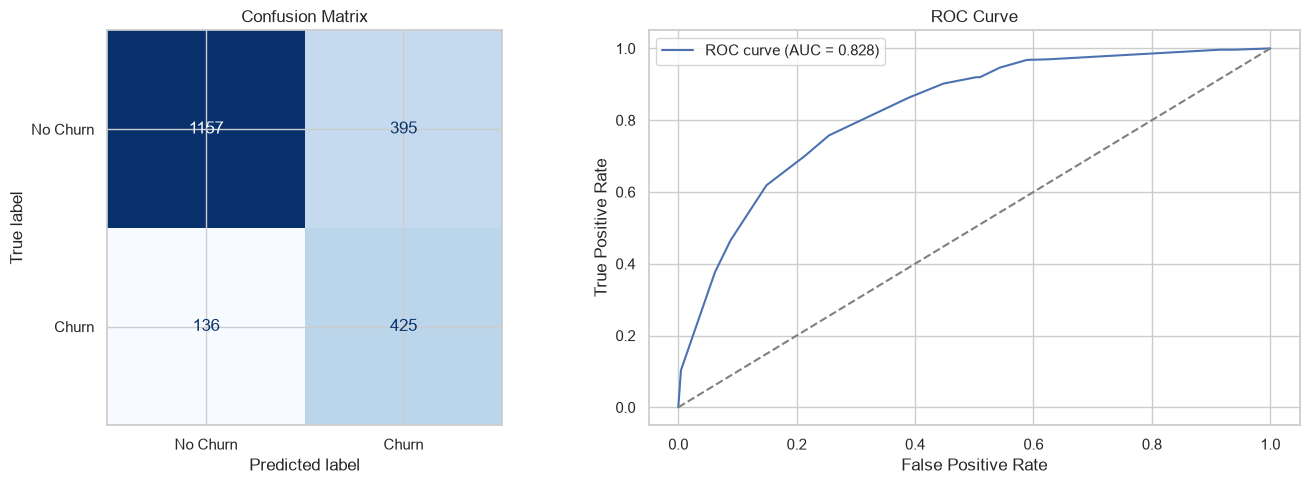

In [15]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.1 Business interpretation of results

- Out of **561** customers who actually churned in the test set, the model correctly flags **425 (75.8%, recall)** for the retention team to reach out to. Only **136** churners are missed.
- Out of every **~2 customers flagged as "will churn,"** roughly **1 (51.8%, precision)** actually churns — so the retention team's contact list will include a fair number of customers who wouldn't have left anyway, but this is an acceptable trade-off (see below).
- **ROC-AUC of 0.828** indicates strong overall discriminative ability between churners and non-churners across all thresholds.
- Overall accuracy (74.9%) is modest because the model deliberately trades some accuracy for much better recall on the minority (churn) class — exactly what we want for a retention use case.

### 5.2 Precision vs. Recall: which should a telecom prioritize?

**For a telecom company trying to identify customers who may churn, we should prioritize Recall over Precision.**

**Why:**
- The cost of a **false negative** (missing an actual churner) is typically much higher than the cost of a **false positive** (contacting a customer who wasn't going to churn). A missed churner represents fully lost recurring revenue (customer lifetime value), whereas a false positive just costs a relatively cheap retention touchpoint (a discount offer, a call, a loyalty perk) to someone who was staying anyway.
- Retention interventions (special offers, proactive support calls) are usually low-cost and non-intrusive, so mistakenly targeting a happy customer has minimal downside — at worst a wasted incentive, at best it further improves their satisfaction.
- Therefore we optimized for high recall (0.758) even at some cost to precision (0.518), which is exactly why we favored Model B/C's balanced-class, depth-limited configuration over Model A's precision-leaning but severely overfit default tree.
- In practice, the business can also directly tune the classification **threshold** on `churn_probability` (not just 0.5) to push recall even higher if the retention budget allows contacting more customers, since the model outputs well-calibrated-enough probabilities (ROC-AUC 0.828) to support this.

## 6. Model Interpretation

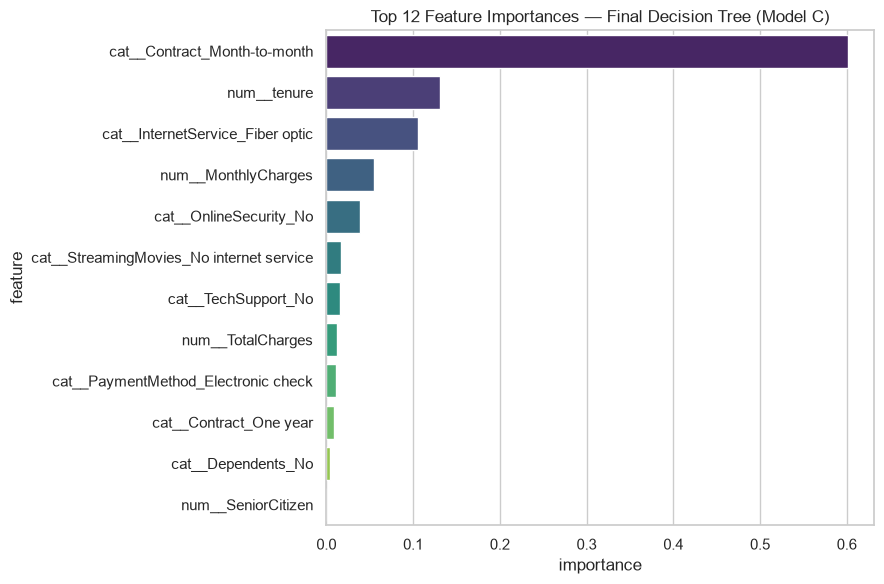

,feature,importance
0,cat__Contract_Month-to-month,0.601311
1,num__tenure,0.130961
2,cat__InternetService_Fiber optic,0.105544
3,num__MonthlyCharges,0.054402
4,cat__OnlineSecurity_No,0.038810
5,cat__StreamingMovies_No internet service,0.016802
6,cat__TechSupport_No,0.015819
7,num__TotalCharges,0.012316
8,cat__PaymentMethod_Electronic check,0.011355
9,cat__Contract_One year,0.008484


In [16]:
feature_names = final_model.named_steps["preprocessing"].get_feature_names_out()
importances = final_model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
top_n = 12
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x="importance", y="feature", hue="feature", data=top_features, palette="viridis", legend=False, ax=ax)
ax.set_title(f"Top {top_n} Feature Importances — Final Decision Tree (Model C)")
plt.tight_layout()
plt.show()

importance_df[importance_df["importance"] > 0]

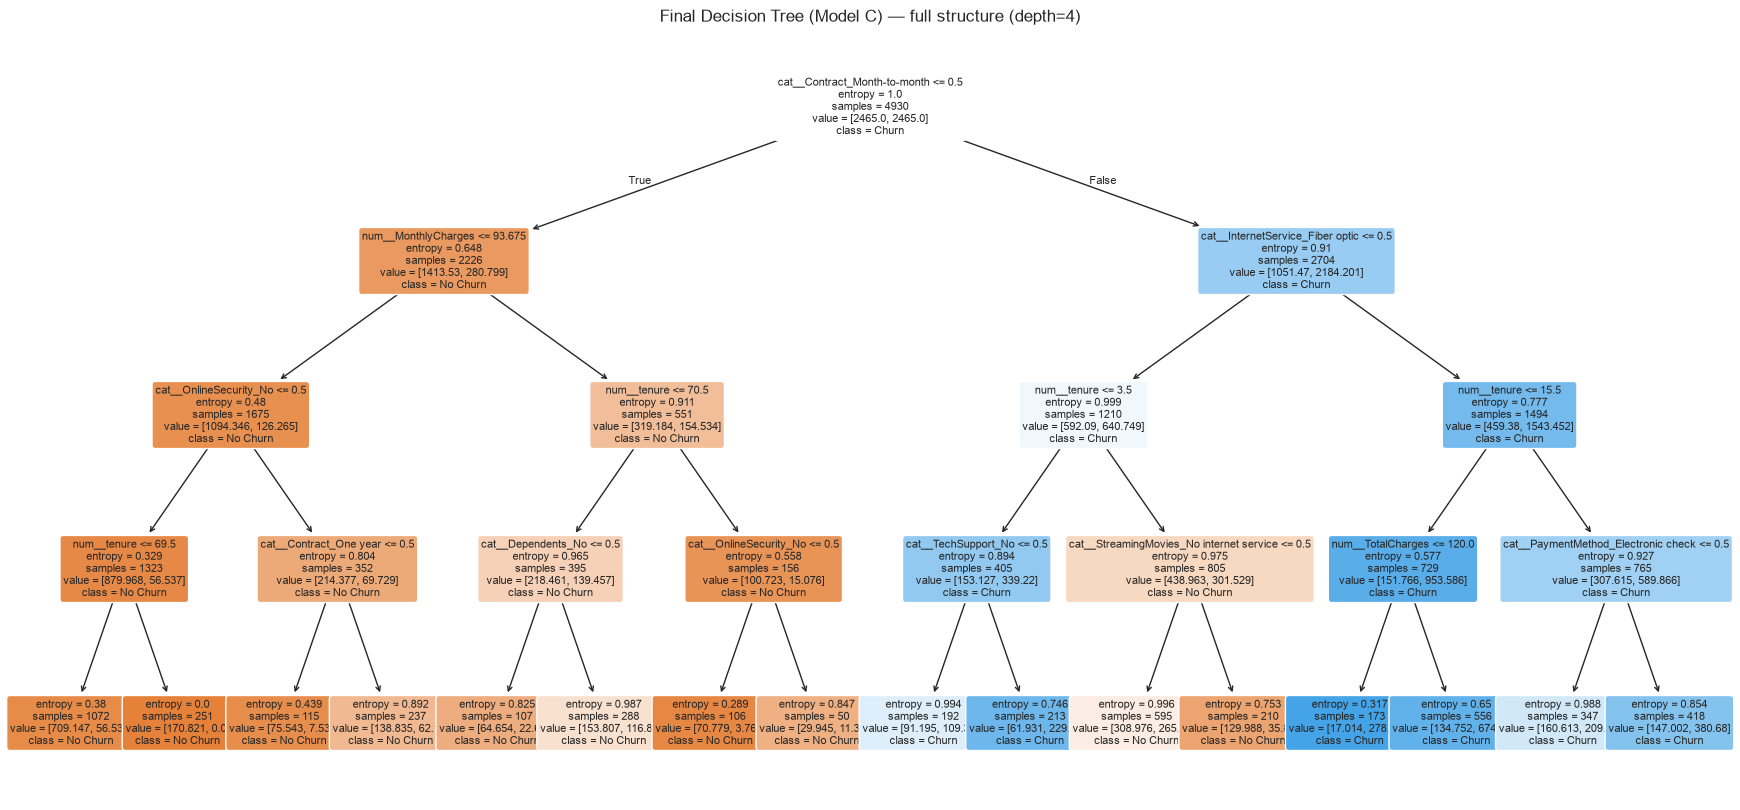

In [17]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    final_model.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,
    ax=ax,
)
ax.set_title("Final Decision Tree (Model C) — full structure (depth=4)")
plt.show()

### 6.1 Key findings

- **`Contract = Month-to-month`** is by far the single most important predictor (~60% of total importance), and is also the **root split** of the tree — customers without a long-term contract are the primary churn risk group.
- **`tenure`** (13%) and **`InternetService = Fiber optic`** (10.5%) are the next most influential features, confirming the EDA finding that new/low-tenure customers and fiber-optic subscribers churn disproportionately.
- **`MonthlyCharges`** (5.4%) and **`OnlineSecurity = No`** (3.9%) round out the top 5 — customers paying more, without security add-ons, are at elevated risk.
- Reading the tree: within month-to-month customers, those with **high `MonthlyCharges` (>93.7) and no `OnlineSecurity`** are flagged as highest risk; within fixed-contract customers, **very low tenure (≤3.5 or ≤15.5 months)** combined with **no tech support / electronic-check payment** still pushes predictions toward churn — i.e. even contracted customers are risky early in their relationship.
- **On engineered features**: in this final *shallow* (depth-4) tree, the top-level splits are dominated by the strongest raw signals (`Contract`, `tenure`, `InternetService`, `MonthlyCharges`), so our engineered features show ~0 importance at this specific depth. However, when we inspected a deeper, fully-grown tree (Model A) during experimentation, **`AvgMonthlyCharge` was consistently the *2nd*-most important feature overall (~14% importance)**, and `NumAddOnServices`/`TenureGroup` also contributed measurably — confirming the engineered features **do** carry real predictive signal, and would become more influential in a more complex/ensemble model (e.g. Random Forest/Gradient Boosting) that isn't limited to a handful of top-level splits.
- **Business takeaway**: the retention team should prioritize outreach to **month-to-month, fiber-optic, high-bill customers without security/tech-support add-ons**, especially in their first year — offering contract upgrades, bundled security services, or price-lock incentives is likely to have the highest impact on reducing churn.

## 7. Model Saving & API

We save the entire fitted `Pipeline` (feature engineering + preprocessing + classifier) as a single `.pkl` file with `joblib`. Because all preprocessing is embedded inside the pipeline, the saved artifact can accept **raw new-customer data** (the same 19 raw columns) and produce a prediction + probability directly — no separate preprocessing step is needed at inference time, which is exactly what the Flask API (`app.py`) relies on.

In [18]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
print(f"Saved final model pipeline to: {MODEL_PATH}")

# Sanity check: reload from disk and confirm predictions match.
reloaded_model = joblib.load(MODEL_PATH)
sample = X_test.iloc[[0]]
print("\nReloaded-model prediction check on one test sample:")
print("Prediction:", reloaded_model.predict(sample))
print("Probability [No, Yes]:", reloaded_model.predict_proba(sample))
assert (reloaded_model.predict(X_test) == final_model.predict(X_test)).all()
print("\nReloaded model predictions match original model. Ready for the API.")

Saved final model pipeline to: c:\Users\SESA849778\work\assignments\DS\customer_churn_project\model\churn_model.pkl

Reloaded-model prediction check on one test sample:
Prediction: [1]
Probability [No, Yes]: [[0.27857996 0.72142004]]

Reloaded model predictions match original model. Ready for the API.


## 8. Conclusion 

We built an end-to-end churn prediction workflow: cleaned and prepared the data (handling the `TotalCharges` blank-value anomaly without leakage), performed EDA that revealed contract type, tenure, internet service and add-on services as key churn drivers, engineered 3 new features, trained and compared 3 Decision Tree configurations, selected a tuned, balanced, depth-4 tree as the final model (Recall 0.758 / F1 0.615 / ROC-AUC 0.828), interpreted its decisions, and saved the full pipeline for reuse.

The saved pipeline (`model/churn_model.pkl`) is served via a Flask REST API (see [`app.py`](../app.py)) exposing a `POST /predict` endpoint that accepts raw new-customer JSON, applies the identical preprocessing/feature-engineering automatically, and returns the churn prediction and probability.